Intervalo da tabela: 1963-11-28 a 2026-08-31
Linhas inválidas substituídas/interpoladas: {'temp_k': 3889, 'dens_cm3': 3325, 'vel_km_s': 2602}


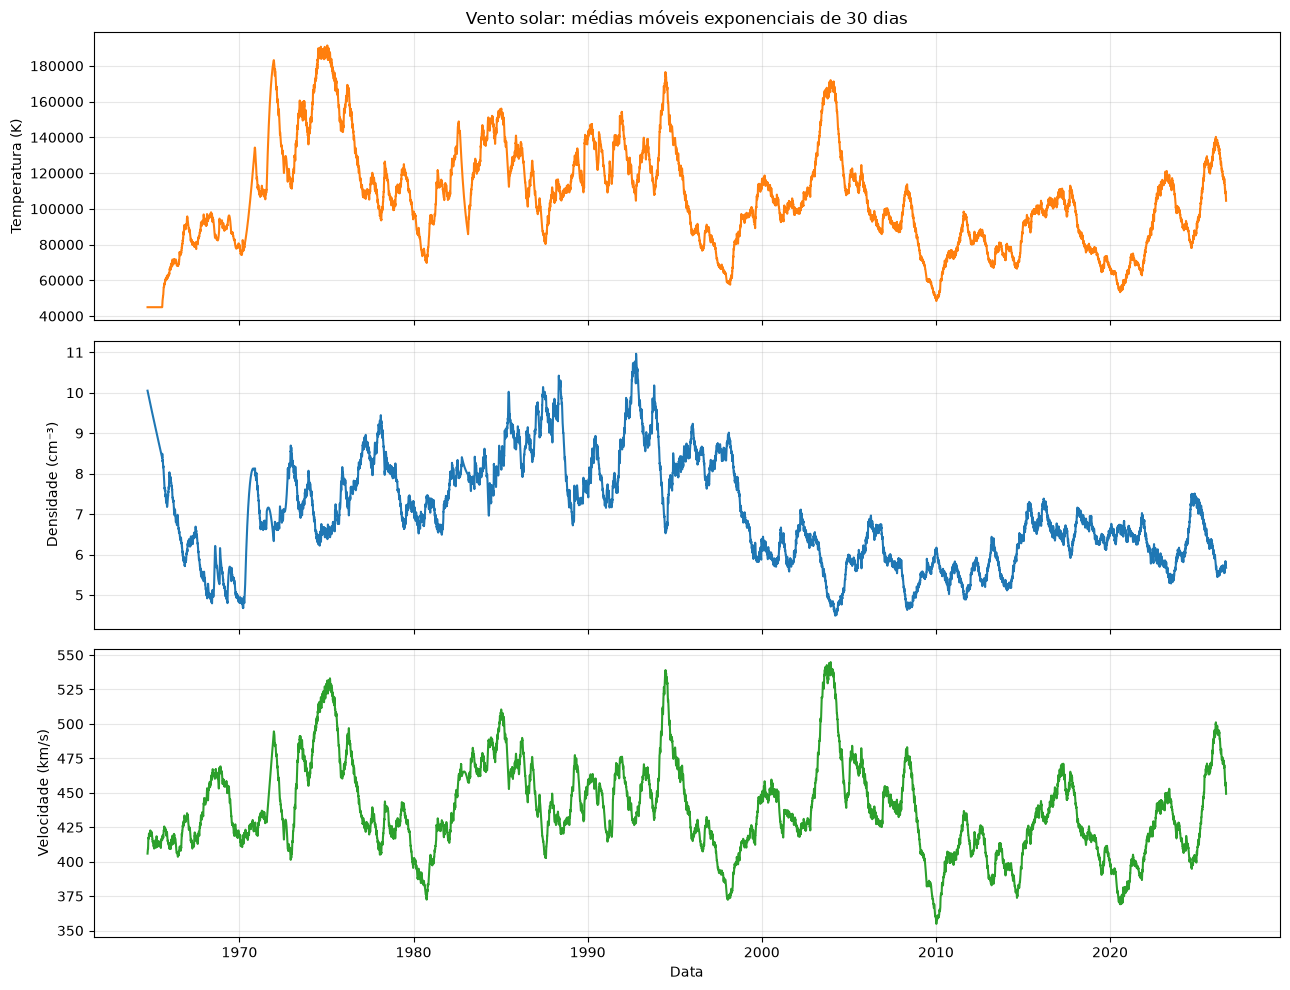

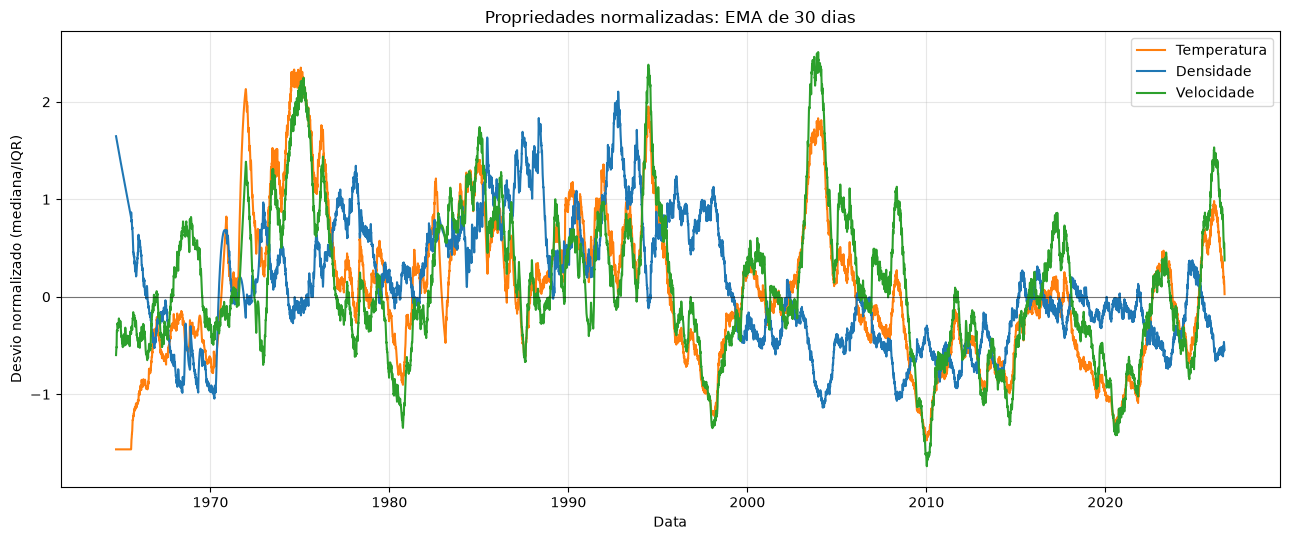

In [1]:
# DIAGNÓSTICO: médias móveis exponenciais de 30 dias
# Esta célula é independente das quatro células anteriores.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EMA_DAYS = 300
SOLAR_CSV = 'atividade_solar.csv'

solar_activity_df = pd.read_csv(
    SOLAR_CSV,
    sep=r'\s+',
    header=None,
    names=['year', 'doy', 'hour', 'temp_k', 'dens_cm3', 'vel_km_s'],
    engine='python',
)

solar_activity_df['date'] = (
    pd.to_datetime(
        solar_activity_df['year'].astype(int).astype(str) + '-01-01'
    )
    + pd.to_timedelta(solar_activity_df['doy'].astype(int) - 1, unit='D')
    + pd.to_timedelta(solar_activity_df['hour'].astype(float), unit='h')
)
solar_activity_df = (
    solar_activity_df.sort_values('date')
    .drop_duplicates('date', keep='first')
    .set_index('date')
)

# Valores fora destes limites são tratados como códigos de preenchimento
# ou medidas inválidas; eles não podem criar falsos picos na EMA.
valid_limits = {
    'temp_k': (0.0, 1.0e6),
    'dens_cm3': (0.0, 100.0),
    'vel_km_s': (200.0, 1000.0),
}
invalid_counts = {}
for column, (lower, upper) in valid_limits.items():
    values = pd.to_numeric(solar_activity_df[column], errors='coerce')
    invalid = (~np.isfinite(values)) | (values <= lower) | (values >= upper)
    invalid_counts[column] = int(invalid.sum())
    solar_activity_df.loc[invalid, column] = np.nan

# Interpolação temporal apenas para preencher lacunas inválidas antes da EMA.
for column in valid_limits:
    solar_activity_df[column] = (
        solar_activity_df[column]
        .interpolate(method='time', limit_direction='both')
    )

ema_30d_df = pd.DataFrame(index=solar_activity_df.index)
for column in valid_limits:
    ema_30d_df[column + '_ema30d'] = (
        solar_activity_df[column]
        .ewm(span=EMA_DAYS, adjust=False, min_periods=EMA_DAYS)
        .mean()
    )

# Padronização robusta: mediana = 0 e intervalo interquartil = 1.
# Isso permite comparar as três grandezas sem misturar suas unidades.
ema_30d_normalized_df = pd.DataFrame(index=ema_30d_df.index)
for column in valid_limits:
    ema_column = column + '_ema30d'
    values = ema_30d_df[ema_column]
    center = values.median()
    scale = values.quantile(0.75) - values.quantile(0.25)
    if not np.isfinite(scale) or scale == 0:
        scale = values.std()
    ema_30d_normalized_df[ema_column] = (values - center) / scale

print('Intervalo da tabela: {} a {}'.format(
    solar_activity_df.index.min().strftime('%Y-%m-%d'),
    solar_activity_df.index.max().strftime('%Y-%m-%d'),
))
print('Linhas inválidas substituídas/interpoladas: {}'.format(invalid_counts))

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
physical_specs = [
    ('temp_k_ema30d', 'Temperatura (K)', 'tab:orange'),
    ('dens_cm3_ema30d', 'Densidade (cm⁻³)', 'tab:blue'),
    ('vel_km_s_ema30d', 'Velocidade (km/s)', 'tab:green'),
]
for axis, (column, ylabel, color) in zip(axes, physical_specs):
    axis.plot(ema_30d_df.index, ema_30d_df[column], color=color)
    axis.set_ylabel(ylabel)
    axis.grid(True, alpha=0.3)
axes[0].set_title('Vento solar: médias móveis exponenciais de 30 dias')
axes[-1].set_xlabel('Data')
fig.tight_layout()
plt.show()
plt.close(fig)

fig, axis = plt.subplots(figsize=(13, 5.5))
normalized_specs = [
    ('temp_k_ema30d', 'Temperatura', 'tab:orange'),
    ('dens_cm3_ema30d', 'Densidade', 'tab:blue'),
    ('vel_km_s_ema30d', 'Velocidade', 'tab:green'),
]
for column, label, color in normalized_specs:
    axis.plot(
        ema_30d_normalized_df.index,
        ema_30d_normalized_df[column],
        color=color,
        label=label,
    )
axis.axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
axis.set_title(
    'Propriedades normalizadas: EMA de 30 dias'
)
axis.set_xlabel('Data')
axis.set_ylabel('Desvio normalizado (mediana/IQR)')
axis.grid(True, alpha=0.3)
axis.legend()
fig.tight_layout()
plt.show()
plt.close(fig)


In [2]:
# SIMULAÇÃO: perfil real direto x perfil real invertido
# Preencha VALLEY_DATE e PEAK_DATE antes de executar esta célula.
import copy
import json
from datetime import datetime, timedelta
from itertools import combinations

import numpy as np
import pandas as pd
from IPython.display import display
from scipy.integrate import RK45
from model.electric_probe import ElectricSailProbe
from solar_sail.electric_sail_dynamic import ElectricSailDynamic
from utils.schemas import RequestDto
from services import n_body_service

required_profile_data = ['solar_activity_df']
missing_profile_data = [
    name for name in required_profile_data if name not in globals()
]
if missing_profile_data:
    raise RuntimeError(
        'Execute primeiro a célula 5. Variáveis ausentes: {}'.format(
            ', '.join(missing_profile_data)
        )
    )

# PARÂMETROS DA COMPARAÇÃO — altere somente estas variáveis
VALLEY_DATE = '2009-01-10'       # exemplo: '2000-01-10'
PEAK_DATE = '2003-01-10'         # exemplo: '2022-01-10'
PHI_REAL_DEG = -30.0
THETA_REAL_DEG = 0.0
MAX_STEP_DAYS_REAL = 1.0

if VALLEY_DATE is None or PEAK_DATE is None:
    raise ValueError(
        'Preencha VALLEY_DATE e PEAK_DATE no formato YYYY-MM-DD.'
    )

valley_requested = pd.Timestamp(VALLEY_DATE)
peak_requested = pd.Timestamp(PEAK_DATE)

def nearest_table_date(requested_date, available_dates):
    distances = np.abs(
        available_dates.to_numpy(dtype='datetime64[ns]')
        - requested_date.to_datetime64()
    )
    return pd.Timestamp(available_dates[np.argmin(distances)])

valley_date = nearest_table_date(
    valley_requested, solar_activity_df.index
)
peak_date = nearest_table_date(
    peak_requested, solar_activity_df.index
)
profile_start = min(valley_date, peak_date)
profile_end = max(valley_date, peak_date)

profile_frame = solar_activity_df.loc[profile_start:profile_end].copy()
if len(profile_frame) < 2:
    raise ValueError(
        'A janela escolhida precisa conter pelo menos dois registros.'
    )

if valley_date < peak_date:
    forward_label = 'Vale → Pico'
    reverse_label = 'Pico → Vale'
else:
    forward_label = 'Pico → Vale'
    reverse_label = 'Vale → Pico'

print(
    'Data de vale solicitada/selecionada: {} / {}'.format(
        valley_requested.strftime('%Y-%m-%d'),
        valley_date.strftime('%Y-%m-%d'),
    )
)
print(
    'Data de pico solicitada/selecionada: {} / {}'.format(
        peak_requested.strftime('%Y-%m-%d'),
        peak_date.strftime('%Y-%m-%d'),
    )
)
print(
    'Janela utilizada: {} a {} ({} registros)'.format(
        profile_start.strftime('%Y-%m-%d'),
        profile_end.strftime('%Y-%m-%d'),
        len(profile_frame),
    )
)

AU_M_REAL = 1.496e11
AU_KM_REAL = AU_M_REAL / 1000.0
MARS_ORBIT_KM_REAL = 1.524 * AU_KM_REAL
G_KM_REAL = 6.6742e-20


class ProfileWind:
    """Perfil temporal sem atraso de propagação, direto ou invertido."""

    def __init__(self, frame, reverse=False):
        frame = frame.sort_index()
        if reverse:
            frame = frame.iloc[::-1]

        self.reverse = reverse
        self.source_dates = pd.DatetimeIndex(frame.index)
        first_date = self.source_dates[0]
        if reverse:
            self.times = np.array([
                (first_date - date).total_seconds()
                for date in self.source_dates
            ])
        else:
            self.times = np.array([
                (date - first_date).total_seconds()
                for date in self.source_dates
            ])

        self.n = frame['dens_cm3'].to_numpy(float) * 1e6
        self.te = frame['temp_k'].to_numpy(float) / 11604.5
        self.v = frame['vel_km_s'].to_numpy(float)

    def at_elapsed(self, elapsed_seconds):
        elapsed = float(np.clip(
            elapsed_seconds, self.times[0], self.times[-1]
        ))
        n = float(np.interp(elapsed, self.times, self.n))
        te = float(np.interp(elapsed, self.times, self.te))
        v = float(np.interp(elapsed, self.times, self.v))
        return n, te, v

    def at_distance(self, elapsed_seconds, radius_m):
        if radius_m <= 0:
            raise ValueError('Distância radial inválida.')
        n1, te1, v = self.at_elapsed(elapsed_seconds)
        scale = AU_M_REAL / radius_m
        return n1 * scale**2, te1 * scale**(1.0 / 3.0), v


def accel_with_profile_wind(body, elapsed_seconds, wind_profile):
    n, te, v = wind_profile.at_distance(
        elapsed_seconds, np.linalg.norm(body.position) * 1000.0
    )
    old = (
        ElectricSailDynamic._n_earth_m3,
        ElectricSailDynamic._t_e_earth_ev,
        ElectricSailDynamic._v_sw_km_s,
    )
    ElectricSailDynamic._n_earth_m3 = n
    ElectricSailDynamic._t_e_earth_ev = te
    ElectricSailDynamic._v_sw_km_s = v
    try:
        return np.asarray(
            ElectricSailDynamic.calculate_acceleration(body),
            dtype=float,
        )
    finally:
        (
            ElectricSailDynamic._n_earth_m3,
            ElectricSailDynamic._t_e_earth_ev,
            ElectricSailDynamic._v_sw_km_s,
        ) = old


def profile_derivatives(t, y, bodies, wind_profile):
    nbody = len(bodies)
    state = np.asarray(y, dtype=float).reshape(2 * nbody, 3)

    for i, body in enumerate(bodies):
        body.position = state[i].copy()
        body.velocity = state[i + nbody].copy()

    acc = np.zeros((nbody, 3), dtype=float)
    for i, j in combinations(range(nbody), 2):
        displacement = bodies[j].position - bodies[i].position
        distance = np.linalg.norm(displacement)
        if distance < bodies[i].radius + bodies[j].radius:
            raise ArithmeticError(
                'Collision detected between {} and {}'.format(
                    bodies[i].name, bodies[j].name
                )
            )
        acc[i] += G_KM_REAL * bodies[j].mass * displacement / distance**3
        acc[j] -= G_KM_REAL * bodies[i].mass * displacement / distance**3

    for i, body in enumerate(bodies):
        if isinstance(body, ElectricSailProbe):
            acc[i] += accel_with_profile_wind(
                body, t, wind_profile
            )

    return np.concatenate((state[nbody:].ravel(), acc.ravel()))


def solve_profile(bodies, wind_profile, time_span):
    positions = [np.asarray(body.position, float) for body in bodies]
    velocities = [np.asarray(body.velocity, float) for body in bodies]
    y0 = np.concatenate([
        np.concatenate(positions),
        np.concatenate(velocities),
    ])
    rows = [np.insert(y0.copy(), 0, 0.0)]
    max_step = min(
        time_span / 1000.0,
        MAX_STEP_DAYS_REAL * 86400.0,
    )
    rk = RK45(
        lambda t, y: profile_derivatives(
            t, y, bodies, wind_profile
        ),
        t0=0.0,
        y0=y0,
        t_bound=time_span,
        max_step=max_step,
        rtol=1e-6,
        atol=1e-9,
    )
    try:
        while rk.status == 'running':
            rk.step()
            rows.append(np.insert(rk.y.copy(), 0, rk.t))
    except ArithmeticError:
        pass
    return np.asarray(rows, dtype=float)


def profile_columns(nbody):
    columns = ['T']
    for i in range(nbody):
        columns += ['X{}'.format(i), 'Y{}'.format(i), 'Z{}'.format(i)]
    for i in range(nbody):
        columns += ['Vx{}'.format(i), 'Vy{}'.format(i), 'Vz{}'.format(i)]
    return columns


with open('../resources/electric_sail_probe.json', 'r') as config_file:
    real_base_config = json.load(config_file)

profile_time_span = (
    profile_end - profile_start
).total_seconds()
profile_wind_forward = ProfileWind(profile_frame, reverse=False)
profile_wind_reverse = ProfileWind(profile_frame, reverse=True)


def run_profile(label, wind_profile):
    config = copy.deepcopy(real_base_config)
    # As datas abaixo servem para o intervalo positivo do integrador.
    # A força vem do perfil direto ou invertido, não da data cronológica.
    config['start_time'] = profile_start.strftime('%Y-%m-%d %H:%M:%S')
    config['end_time'] = profile_end.strftime('%Y-%m-%d %H:%M:%S')
    config['electric_sail_probes'][0]['phi_deg'] = float(PHI_REAL_DEG)
    config['electric_sail_probes'][0]['theta_deg'] = float(THETA_REAL_DEG)

    bodies, span = n_body_service.process_data(
        RequestDto().load(config)
    )
    y = solve_profile(bodies, wind_profile, span)
    df = pd.DataFrame(
        y, columns=profile_columns(len(bodies))
    )

    relative = df[['X1', 'Y1', 'Z1']].to_numpy() - df[
        ['X0', 'Y0', 'Z0']
    ].to_numpy()
    radius_km = np.linalg.norm(relative, axis=1)
    crossings = np.where(radius_km >= MARS_ORBIT_KM_REAL)[0]
    cross_idx = int(crossings[0]) if len(crossings) else None
    arrival_days = (
        float(df['T'].iloc[cross_idx] / 86400.0)
        if cross_idx is not None else None
    )

    # bodies[0] é o Sol (referência usada em todo o notebook: X0/Y0/Z0).
    # Pegamos a massa diretamente dos corpos da simulação para que mu
    # (G_KM_REAL * massa_sol) seja exatamente o mesmo usado na integração,
    # em vez de um valor padrão hard-coded.
    mu_km3_s2 = G_KM_REAL * bodies[0].mass

    return {
        'label': label,
        'df': df,
        'radius_km': radius_km,
        'arrival_days': arrival_days,
        'wind_profile': wind_profile,
        'config': config,
        'mu_km3_s2': mu_km3_s2,
    }


forward_run = run_profile(forward_label, profile_wind_forward)
reverse_run = run_profile(reverse_label, profile_wind_reverse)

print(
    'Simulações concluídas: {} ({} pontos) e {} ({} pontos).'.format(
        forward_run['label'],
        len(forward_run['df']),
        reverse_run['label'],
        len(reverse_run['df']),
    )
)


Data de vale solicitada/selecionada: 2009-01-10 / 2009-01-10
Data de pico solicitada/selecionada: 2003-01-10 / 2003-01-10
Janela utilizada: 2003-01-10 a 2009-01-10 (2193 registros)
Simulações concluídas: Pico → Vale (2243 pontos) e Vale → Pico (2248 pontos).


In [3]:
# COMPARAÇÃO NUMÉRICA: perfil direto x perfil invertido
import numpy as np
import pandas as pd
from IPython.display import display

required_runs_real = ['forward_run', 'reverse_run', 'profile_start', 'profile_end']
missing_runs_real = [
    name for name in required_runs_real if name not in globals()
]
if missing_runs_real:
    raise RuntimeError(
        'Execute primeiro a célula 6. Variáveis ausentes: {}'.format(
            ', '.join(missing_runs_real)
        )
    )

mission_days_real = (
    profile_end - profile_start
).total_seconds() / 86400.0
checkpoint_fractions_real = [0.5, 1.0]


def distance_at_elapsed(run, elapsed_days):
    target = float(elapsed_days) * 86400.0
    times = run['df']['T'].to_numpy(dtype=float)
    idx = int(np.searchsorted(times, target))
    idx = min(idx, len(times) - 1)
    return float(run['radius_km'][idx]) / AU_KM_REAL


comparison_rows_real = []
for run in (forward_run, reverse_run):
    row = {
        'cenario': run['label'],
        'tempo_chegada_marte_dias': run['arrival_days'],
    }
    for fraction in checkpoint_fractions_real:
        days = mission_days_real * fraction
        row['dist_{:.0f}_porcento_UA'.format(fraction * 100)] = (
            distance_at_elapsed(run, days)
        )
    row['dist_final_UA'] = (
        float(run['radius_km'][-1]) / AU_KM_REAL
    )
    comparison_rows_real.append(row)

comparison_real_df = pd.DataFrame(comparison_rows_real)
display(comparison_real_df)

diff_final_real = (
    reverse_run['radius_km'][-1] - forward_run['radius_km'][-1]
) / AU_KM_REAL
print(
    'Diferença de distância final (invertido - direto): '
    '{:+.4f} UA'.format(diff_final_real)
)

diff_arrival_real = None
if (
    forward_run['arrival_days'] is not None
    and reverse_run['arrival_days'] is not None
):
    diff_arrival_real = (
        reverse_run['arrival_days'] - forward_run['arrival_days']
    )
    print(
        'Diferença de tempo de chegada (invertido - direto): '
        '{:+.4f} dias'.format(diff_arrival_real)
    )

ranking_real_df = comparison_real_df.sort_values(
    'dist_final_UA',
    ascending=False,
).reset_index(drop=True)

print('Ranking final pela distância heliocêntrica:')
for position, row in ranking_real_df.iterrows():
    print(
        '{}. {}: {:.4f} UA'.format(
            position + 1,
            row['cenario'],
            row['dist_final_UA'],
        )
    )


,cenario,tempo_chegada_marte_dias,dist_50_porcento_UA,dist_100_porcento_UA,dist_final_UA
0,Pico → Vale,174.572335,2.455796,3.109813,3.109813
1,Vale → Pico,245.826605,1.931845,2.154193,2.154193


Diferença de distância final (invertido - direto): -0.9556 UA
Diferença de tempo de chegada (invertido - direto): +71.2543 dias
Ranking final pela distância heliocêntrica:
1. Pico → Vale: 3.1098 UA
2. Vale → Pico: 2.1542 UA


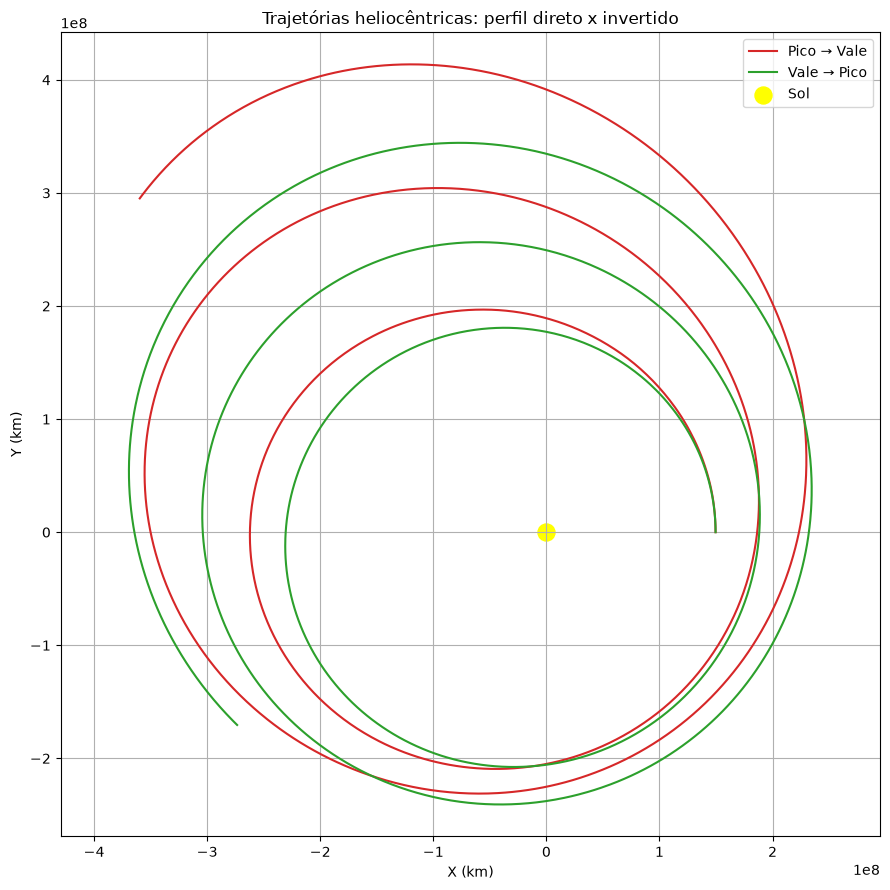

In [4]:
# TRAJETÓRIAS: perfil direto x perfil invertido

import matplotlib.pyplot as plt

required_traj_real = ['forward_run', 'reverse_run']
missing_traj_real = [
    name for name in required_traj_real if name not in globals()
]
if missing_traj_real:
    raise RuntimeError(
        'Execute primeiro a célula 6. Variáveis ausentes: {}'.format(
            ', '.join(missing_traj_real)
        )
    )

trajectory_colors_real = {
    forward_run['label']: 'tab:red',
    reverse_run['label']: 'tab:green',
}

fig, ax = plt.subplots(figsize=(9, 9))
ax.axis('equal')

for run in (forward_run, reverse_run):
    x_relative = run['df']['X1'] - run['df']['X0']
    y_relative = run['df']['Y1'] - run['df']['Y0']
    ax.plot(
        x_relative,
        y_relative,
        color=trajectory_colors_real[run['label']],
        label=run['label'],
    )

ax.scatter(0, 0, s=150, color='yellow', label='Sol')
ax.set_title(
    'Trajetórias heliocêntricas: perfil direto x invertido'
)
ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)


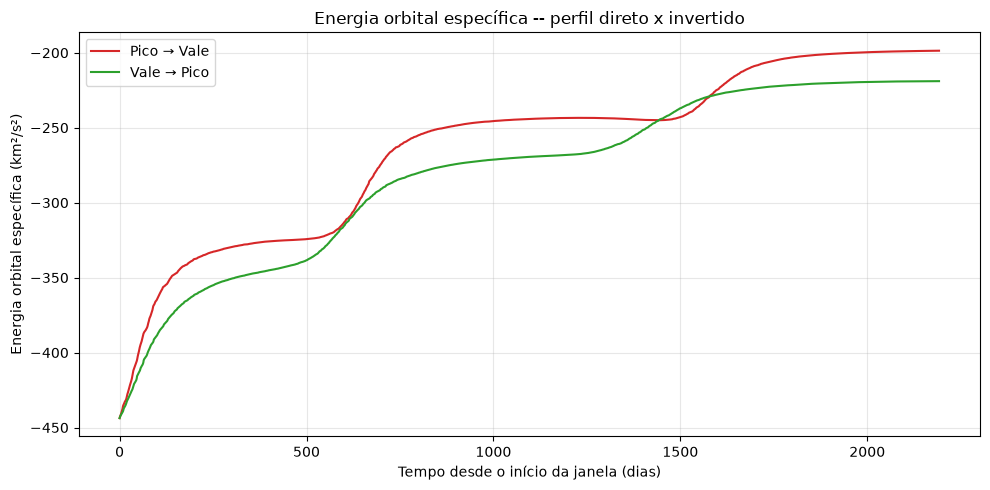

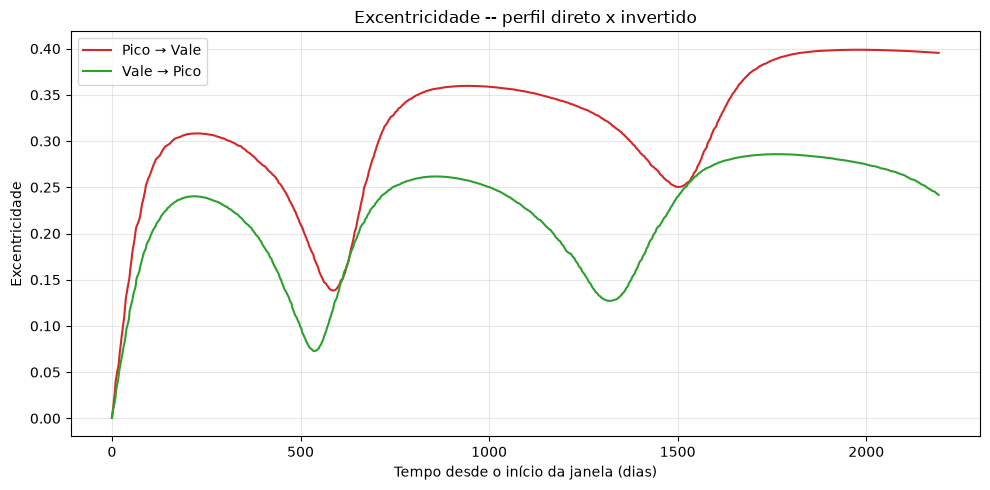

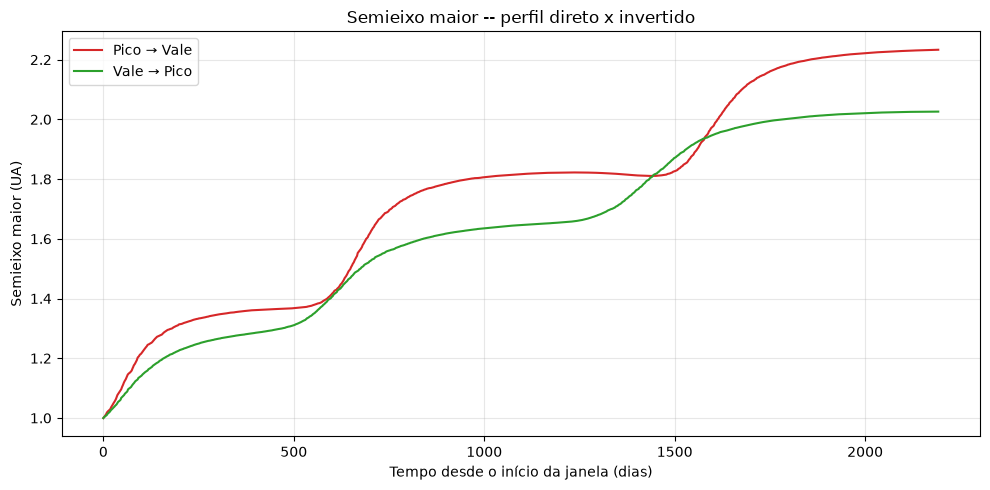

In [5]:
# ELEMENTOS ORBITAIS: energia específica, excentricidade e semieixo maior
# (problema de dois corpos, sonda relativa ao Sol) -- perfil direto x
# invertido.
#
# Como a vela elétrica aplica empuxo não-gravitacional, esses elementos
# variam ao longo do tempo (não são constantes como numa órbita
# kepleriana pura) -- é justamente essa variação que queremos observar.

import numpy as np
import matplotlib.pyplot as plt

required_orbital_real = ['forward_run', 'reverse_run']
missing_orbital_real = [
    name for name in required_orbital_real if name not in globals()
]
if missing_orbital_real:
    raise RuntimeError(
        'Execute primeiro a célula 6. Variáveis ausentes: {}'.format(
            ', '.join(missing_orbital_real)
        )
    )


def orbital_elements_real(run):
    """Energia específica, excentricidade e semieixo maior (dois corpos,
    sonda relativa ao Sol) em cada instante simulado.

    mu = G_KM_REAL * massa_do_sol é obtido diretamente dos corpos usados
    na simulação (guardado em run['mu_km3_s2']), garantindo consistência
    com a dinâmica realmente integrada.
    """
    df_run = run['df']
    mu = run['mu_km3_s2']

    r_vec = (
        df_run[['X1', 'Y1', 'Z1']].to_numpy()
        - df_run[['X0', 'Y0', 'Z0']].to_numpy()
    )
    v_vec = (
        df_run[['Vx1', 'Vy1', 'Vz1']].to_numpy()
        - df_run[['Vx0', 'Vy0', 'Vz0']].to_numpy()
    )

    r = np.linalg.norm(r_vec, axis=1)
    v = np.linalg.norm(v_vec, axis=1)

    specific_energy = 0.5 * v**2 - mu / r

    h_vec = np.cross(r_vec, v_vec)
    e_vec = np.cross(v_vec, h_vec) / mu - r_vec / r[:, None]
    eccentricity = np.linalg.norm(e_vec, axis=1)

    with np.errstate(divide='ignore', invalid='ignore'):
        semi_major_axis_km = np.where(
            specific_energy != 0.0, -mu / (2.0 * specific_energy), np.nan
        )
    semi_major_axis_AU = semi_major_axis_km / AU_KM_REAL

    return {
        'elapsed_days': df_run['T'].to_numpy() / 86400.0,
        'specific_energy_km2_s2': specific_energy,
        'eccentricity': eccentricity,
        'semi_major_axis_AU': semi_major_axis_AU,
    }


forward_orbital = orbital_elements_real(forward_run)
reverse_orbital = orbital_elements_real(reverse_run)

orbital_colors_real = {
    forward_run['label']: 'tab:red',
    reverse_run['label']: 'tab:green',
}
orbital_runs_real = (
    (forward_run, forward_orbital),
    (reverse_run, reverse_orbital),
)


def plot_orbital_element_real(field, ylabel, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    for run, elements in orbital_runs_real:
        color = orbital_colors_real[run['label']]
        ax.plot(
            elements['elapsed_days'], elements[field],
            color=color, label=run['label'],
        )

    ax.set_xlabel('Tempo desde o início da janela (dias)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()


plot_orbital_element_real(
    'specific_energy_km2_s2',
    'Energia orbital específica (km²/s²)',
    'Energia orbital específica -- perfil direto x invertido',
)
plot_orbital_element_real(
    'eccentricity',
    'Excentricidade',
    'Excentricidade -- perfil direto x invertido',
)
plot_orbital_element_real(
    'semi_major_axis_AU',
    'Semieixo maior (UA)',
    'Semieixo maior -- perfil direto x invertido',
)


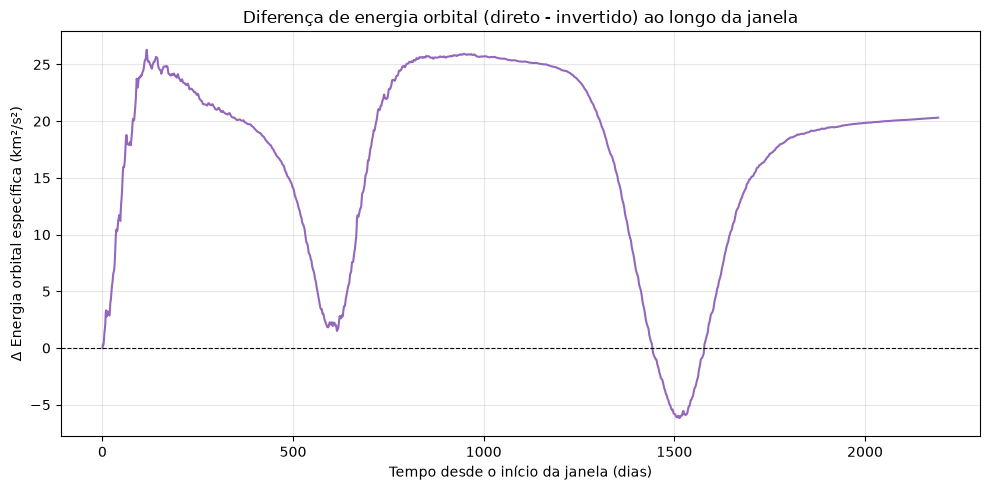

In [6]:
# DIFERENÇA DE ENERGIA ORBITAL: direto - invertido
#
# Como as duas simulações têm grades de tempo distintas (o RK45 usa passo
# adaptativo), interpolamos ambas as séries de energia num eixo de tempo
# comum antes de subtrair.

import numpy as np
import matplotlib.pyplot as plt

required_energy_diff_real = ['forward_orbital', 'reverse_orbital']
missing_energy_diff_real = [
    name for name in required_energy_diff_real if name not in globals()
]
if missing_energy_diff_real:
    raise RuntimeError(
        'Execute primeiro a célula de elementos orbitais. '
        'Variáveis ausentes: {}'.format(', '.join(missing_energy_diff_real))
    )

common_max_days_real = min(
    forward_orbital['elapsed_days'][-1], reverse_orbital['elapsed_days'][-1]
)
common_days_real = np.linspace(0.0, common_max_days_real, 2000)

forward_energy_common = np.interp(
    common_days_real, forward_orbital['elapsed_days'],
    forward_orbital['specific_energy_km2_s2'],
)
reverse_energy_common = np.interp(
    common_days_real, reverse_orbital['elapsed_days'],
    reverse_orbital['specific_energy_km2_s2'],
)

energy_diff_km2_s2_real = forward_energy_common - reverse_energy_common

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(common_days_real, energy_diff_km2_s2_real, color='tab:purple')
ax.axhline(0.0, color='black', linewidth=0.8, linestyle='--')

ax.set_xlabel('Tempo desde o início da janela (dias)')
ax.set_ylabel('Δ Energia orbital específica (km²/s²)')
ax.set_title(
    'Diferença de energia orbital (direto - invertido) ao longo da janela'
)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


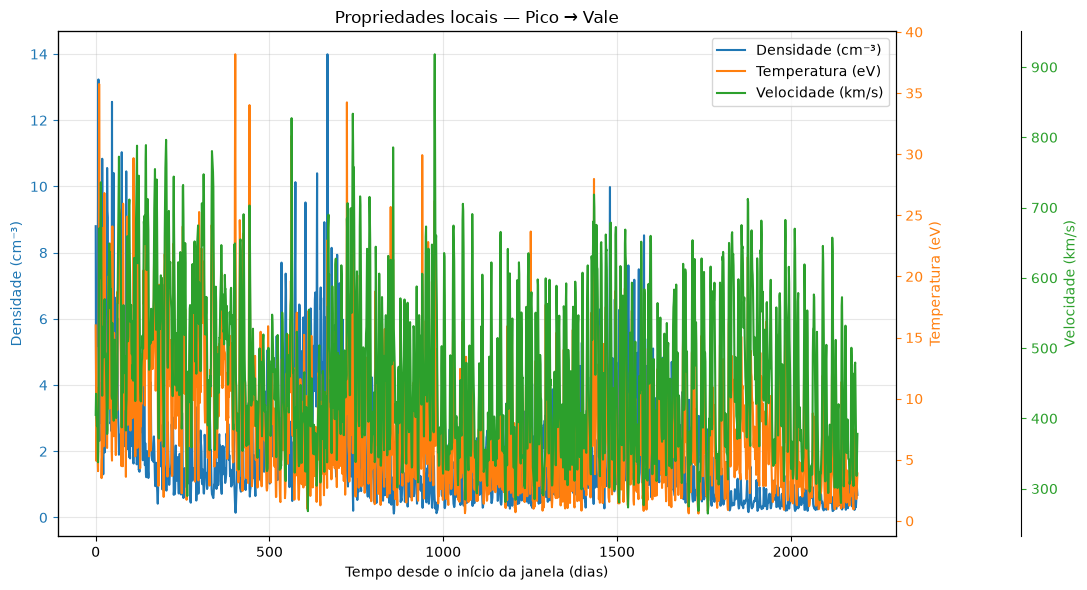

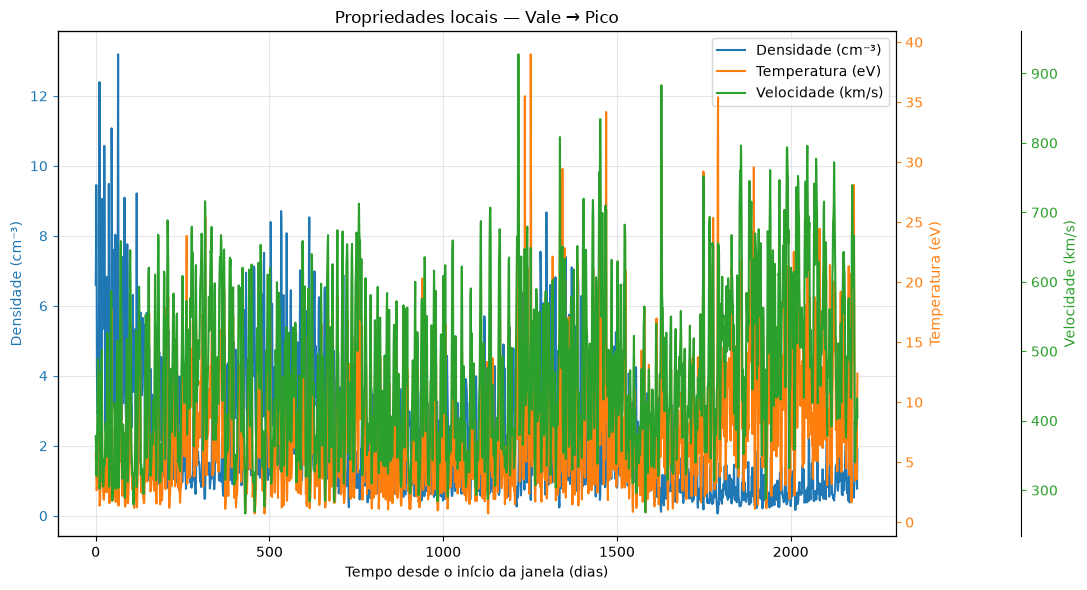

In [7]:
# PROPRIEDADES LOCAIS: perfil direto x perfil invertido

import numpy as np
import matplotlib.pyplot as plt

required_wind_real = [
    'forward_run', 'reverse_run', 'profile_wind_forward',
    'profile_wind_reverse',
]
missing_wind_real = [
    name for name in required_wind_real if name not in globals()
]
if missing_wind_real:
    raise RuntimeError(
        'Execute primeiro a célula 6. Variáveis ausentes: {}'.format(
            ', '.join(missing_wind_real)
        )
    )

MAX_PROFILE_POINTS_REAL = 3000


def local_wind_profile_real(run, max_points=MAX_PROFILE_POINTS_REAL):
    df_run = run['df']
    n_rows = len(df_run)
    step = max(1, n_rows // max_points)
    sample_indices = np.arange(0, n_rows, step)

    elapsed_days = []
    density_cm3 = []
    temperature_eV = []
    speed_km_s = []

    for index in sample_indices:
        row = df_run.iloc[index]
        elapsed_seconds = float(row['T'])
        relative = np.array([
            row['X1'] - row['X0'],
            row['Y1'] - row['Y0'],
            row['Z1'] - row['Z0'],
        ])
        radius_m = float(np.linalg.norm(relative)) * 1000.0
        n, te, v = run['wind_profile'].at_distance(
            elapsed_seconds, radius_m
        )

        elapsed_days.append(elapsed_seconds / 86400.0)
        density_cm3.append(n / 1e6)
        temperature_eV.append(te)
        speed_km_s.append(v)

    return {
        'elapsed_days': np.asarray(elapsed_days),
        'density_cm3': np.asarray(density_cm3),
        'temperature_eV': np.asarray(temperature_eV),
        'speed_km_s': np.asarray(speed_km_s),
    }


def plot_wind_triple_real(run, profile):
    color_density = 'tab:blue'
    color_temperature = 'tab:orange'
    color_speed = 'tab:green'

    fig, ax1 = plt.subplots(figsize=(11, 6))
    ax2 = ax1.twinx()
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('axes', 1.15))

    line1, = ax1.plot(
        profile['elapsed_days'],
        profile['density_cm3'],
        color=color_density,
        label='Densidade (cm⁻³)',
    )
    line2, = ax2.plot(
        profile['elapsed_days'],
        profile['temperature_eV'],
        color=color_temperature,
        label='Temperatura (eV)',
    )
    line3, = ax3.plot(
        profile['elapsed_days'],
        profile['speed_km_s'],
        color=color_speed,
        label='Velocidade (km/s)',
    )

    ax1.set_xlabel('Tempo desde o início da janela (dias)')
    ax1.set_ylabel('Densidade (cm⁻³)', color=color_density)
    ax2.set_ylabel('Temperatura (eV)', color=color_temperature)
    ax3.set_ylabel('Velocidade (km/s)', color=color_speed)
    ax1.tick_params(axis='y', colors=color_density)
    ax2.tick_params(axis='y', colors=color_temperature)
    ax3.tick_params(axis='y', colors=color_speed)
    ax1.set_title(
        'Propriedades locais — {}'.format(run['label'])
    )
    ax1.legend(
        [line1, line2, line3],
        [line1.get_label(), line2.get_label(), line3.get_label()],
        loc='upper right',
    )
    ax1.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


forward_profile_real = local_wind_profile_real(forward_run)
reverse_profile_real = local_wind_profile_real(reverse_run)

plot_wind_triple_real(forward_run, forward_profile_real)
plot_wind_triple_real(reverse_run, reverse_profile_real)


In [8]:
# NOVO EXPERIMENTO: eventos cronológicos deslocados
import copy
import json
from datetime import timedelta

import numpy as np
import pandas as pd
from IPython.display import display

# Durações padrão; altere esta lista para testar outros horizontes.
MISSION_YEARS_BATCH = [6, 11, 22, 44]

# Datas configuráveis. O par padrão abaixo deixa espaço na tabela atual
# para completar as duas missões de 44 anos.
START_EVENT_TYPE_BATCH = 'peak'  # 'peak' ou 'valley'
START_EVENT_DATE_BATCH = '1974-09-01'
NEXT_EVENT_DATE_BATCH = '1980-01-01'

# A orientação e o passo continuam seguindo o experimento anterior.
PHI_BATCH_DEG = -30.0
THETA_BATCH_DEG = 0.0
MARS_ORBIT_KM_BATCH = MARS_ORBIT_KM_REAL

if START_EVENT_TYPE_BATCH not in ('peak', 'valley'):
    raise ValueError("START_EVENT_TYPE_BATCH deve ser 'peak' ou 'valley'.")

def nearest_batch_date(requested_date, available_dates):
    requested = pd.Timestamp(requested_date)
    distances = np.abs(
        available_dates.to_numpy(dtype='datetime64[ns]')
        - requested.to_datetime64()
    )
    return pd.Timestamp(available_dates[np.argmin(distances)])

batch_start_date = nearest_batch_date(
    START_EVENT_DATE_BATCH,
    solar_activity_df.index,
)
batch_next_date = nearest_batch_date(
    NEXT_EVENT_DATE_BATCH,
    solar_activity_df.index,
)

if batch_next_date <= batch_start_date:
    raise ValueError(
        'NEXT_EVENT_DATE_BATCH precisa ser posterior a START_EVENT_DATE_BATCH.'
    )

if START_EVENT_TYPE_BATCH == 'peak':
    batch_first_label = 'Pico inicial'
    batch_second_label = 'Vale seguinte'
else:
    batch_first_label = 'Vale inicial'
    batch_second_label = 'Pico seguinte'

batch_event_starts = [
    (batch_first_label, batch_start_date),
    (batch_second_label, batch_next_date),
]

table_min_date = pd.Timestamp(solar_activity_df.index.min())
table_max_date = pd.Timestamp(solar_activity_df.index.max())

batch_coverage_rows = []
for mission_years in MISSION_YEARS_BATCH:
    duration = timedelta(days=float(mission_years) * 365.25)
    for label, launch_date in batch_event_starts:
        end_date = launch_date + duration
        batch_coverage_rows.append({
            'mission_years': mission_years,
            'scenario': label,
            'launch_date': launch_date,
            'end_date': end_date,
            'inside_table': (
                launch_date >= table_min_date
                and end_date <= table_max_date
            ),
        })

batch_coverage_df = pd.DataFrame(batch_coverage_rows)
display(batch_coverage_df)

if not bool(batch_coverage_df['inside_table'].all()):
    invalid = batch_coverage_df.loc[
        ~batch_coverage_df['inside_table']
    ]
    raise ValueError(
        'A tabela não cobre todas as missões. Ajuste as datas ou forneça '
        'dados até depois de: {}'.format(
            invalid['end_date'].max().strftime('%Y-%m-%d')
        )
    )

print(
    'Eventos usados: {} em {} e {} em {}.'.format(
        batch_first_label,
        batch_start_date.strftime('%Y-%m-%d'),
        batch_second_label,
        batch_next_date.strftime('%Y-%m-%d'),
    )
)
print('Cobertura da tabela: {} a {}.'.format(
    table_min_date.strftime('%Y-%m-%d'),
    table_max_date.strftime('%Y-%m-%d'),
))

,mission_years,scenario,launch_date,end_date,inside_table
0,6,Pico inicial,1974-09-01,1980-08-31 12:00:00,True
1,6,Vale seguinte,1980-01-01,1985-12-31 12:00:00,True
2,11,Pico inicial,1974-09-01,1985-08-31 18:00:00,True
3,11,Vale seguinte,1980-01-01,1990-12-31 18:00:00,True
4,22,Pico inicial,1974-09-01,1996-08-31 12:00:00,True
5,22,Vale seguinte,1980-01-01,2001-12-31 12:00:00,True
6,44,Pico inicial,1974-09-01,2018-09-01 00:00:00,True
7,44,Vale seguinte,1980-01-01,2024-01-01 00:00:00,True


Eventos usados: Pico inicial em 1974-09-01 e Vale seguinte em 1980-01-01.
Cobertura da tabela: 1963-11-28 a 2026-08-31.


In [9]:
# Construção dos perfis cronológicos, sem inversão temporal

def mission_frame_from_table(launch_date, end_date):
    launch_date = pd.Timestamp(launch_date)
    end_date = pd.Timestamp(end_date)

    if launch_date < table_min_date or end_date > table_max_date:
        raise ValueError(
            'Missão fora da cobertura da tabela: {} a {}.'.format(
                launch_date.strftime('%Y-%m-%d'),
                end_date.strftime('%Y-%m-%d'),
            )
        )

    frame = solar_activity_df.loc[launch_date:end_date].copy()

    # Garante valores nos dois extremos exatos da missão por interpolação
    # temporal; nenhum valor é invertido ou repetido fora da tabela.
    endpoints = pd.DatetimeIndex([launch_date, end_date])
    frame = frame.reindex(
        frame.index.union(endpoints)
    ).sort_index()

    value_columns = ['temp_k', 'dens_cm3', 'vel_km_s']
    frame[value_columns] = (
        frame[value_columns]
        .interpolate(method='time', limit_direction='both')
    )

    return frame.loc[launch_date:end_date, value_columns].copy()


def build_chronological_profile(launch_date, mission_years):
    end_date = (
        pd.Timestamp(launch_date)
        + pd.to_timedelta(float(mission_years) * 365.25, unit='D')
    )
    frame = mission_frame_from_table(launch_date, end_date)
    if len(frame) < 2:
        raise ValueError('O perfil precisa conter pelo menos dois registros.')

    # reverse permanece sempre False: cada missão usa a tabela no sentido
    # cronológico correspondente à sua própria data de lançamento.
    profile = ProfileWind(frame, reverse=False)
    return profile, end_date, frame


batch_profile_specs = []
for mission_years in MISSION_YEARS_BATCH:
    for label, launch_date in batch_event_starts:
        profile, end_date, frame = build_chronological_profile(
            launch_date,
            mission_years,
        )
        batch_profile_specs.append({
            'mission_years': mission_years,
            'scenario': label,
            'launch_date': pd.Timestamp(launch_date),
            'end_date': pd.Timestamp(end_date),
            'wind_profile': profile,
            'wind_frame': frame,
        })

batch_profile_summary = pd.DataFrame([
    {
        'mission_years': spec['mission_years'],
        'scenario': spec['scenario'],
        'launch_date': spec['launch_date'],
        'end_date': spec['end_date'],
        'table_rows': len(spec['wind_frame']),
        'chronological': True,
    }
    for spec in batch_profile_specs
])
display(batch_profile_summary)

,mission_years,scenario,launch_date,end_date,table_rows,chronological
0,6,Pico inicial,1974-09-01,1980-08-31 12:00:00,2193,True
1,6,Vale seguinte,1980-01-01,1985-12-31 12:00:00,2193,True
2,11,Pico inicial,1974-09-01,1985-08-31 18:00:00,4019,True
3,11,Vale seguinte,1980-01-01,1990-12-31 18:00:00,4019,True
4,22,Pico inicial,1974-09-01,1996-08-31 12:00:00,8037,True
5,22,Vale seguinte,1980-01-01,2001-12-31 12:00:00,8037,True
6,44,Pico inicial,1974-09-01,2018-09-01 00:00:00,16072,True
7,44,Vale seguinte,1980-01-01,2024-01-01 00:00:00,16072,True


In [10]:
# Execução das duas missões para cada duração

if 'real_base_config' not in globals():
    with open('../resources/electric_sail_probe.json', 'r') as config_file:
        real_base_config = json.load(config_file)


def first_mars_crossing(df_run, threshold_km):
    relative = (
        df_run[['X1', 'Y1', 'Z1']].to_numpy(dtype=float)
        - df_run[['X0', 'Y0', 'Z0']].to_numpy(dtype=float)
    )
    radius_km = np.linalg.norm(relative, axis=1)
    crossing_indices = np.flatnonzero(radius_km >= threshold_km)

    if len(crossing_indices) == 0:
        return radius_km, None, None, None

    index = int(crossing_indices[0])
    times = df_run['T'].to_numpy(dtype=float)

    if index == 0:
        crossing_seconds = float(times[0])
        crossing_position = relative[0].copy()
    else:
        r0 = float(radius_km[index - 1])
        r1 = float(radius_km[index])
        if r1 == r0:
            fraction = 0.0
        else:
            fraction = (threshold_km - r0) / (r1 - r0)
            fraction = float(np.clip(fraction, 0.0, 1.0))
        crossing_seconds = (
            times[index - 1]
            + fraction * (times[index] - times[index - 1])
        )
        crossing_position = (
            relative[index - 1]
            + fraction * (relative[index] - relative[index - 1])
        )

    return (
        radius_km,
        index,
        crossing_seconds / 86400.0,
        crossing_position,
    )


def run_chronological_mission(spec):
    config = copy.deepcopy(real_base_config)
    config['start_time'] = spec['launch_date'].strftime(
        '%Y-%m-%d %H:%M:%S'
    )
    config['end_time'] = spec['end_date'].strftime(
        '%Y-%m-%d %H:%M:%S'
    )
    config['electric_sail_probes'][0]['phi_deg'] = float(PHI_BATCH_DEG)
    config['electric_sail_probes'][0]['theta_deg'] = float(THETA_BATCH_DEG)

    bodies, span = n_body_service.process_data(
        RequestDto().load(config)
    )
    y = solve_profile(
        bodies,
        spec['wind_profile'],
        span,
    )
    df_run = pd.DataFrame(
        y,
        columns=profile_columns(len(bodies)),
    )

    radius_km, crossing_index, crossing_days, crossing_position = (
        first_mars_crossing(df_run, MARS_ORBIT_KM_BATCH)
    )

    simulated_days = float(df_run['T'].iloc[-1] / 86400.0)
    requested_days = float(span / 86400.0)

    return {
        **spec,
        'df': df_run,
        'radius_km': radius_km,
        'mars_crossing_index': crossing_index,
        'mars_crossing_days': crossing_days,
        'mars_crossing_position_km': crossing_position,
        'simulated_days': simulated_days,
        'requested_days': requested_days,
        'completed_to_end': simulated_days >= requested_days - 1e-6,
        'mu_km3_s2': G_KM_REAL * bodies[0].mass,
    }


shifted_runs = {}
for spec in batch_profile_specs:
    key = (spec['mission_years'], spec['scenario'])
    print(
        'Executando {} anos — {} ({} a {}).'.format(
            spec['mission_years'],
            spec['scenario'],
            spec['launch_date'].strftime('%Y-%m-%d'),
            spec['end_date'].strftime('%Y-%m-%d'),
        )
    )
    shifted_runs[key] = run_chronological_mission(spec)

print('Simulações concluídas:', len(shifted_runs))
print(
    'Todas chegaram ao fim solicitado:',
    all(run['completed_to_end'] for run in shifted_runs.values()),
)

Executando 6 anos — Pico inicial (1974-09-01 a 1980-08-31).
Executando 6 anos — Vale seguinte (1980-01-01 a 1985-12-31).
Executando 11 anos — Pico inicial (1974-09-01 a 1985-08-31).
Executando 11 anos — Vale seguinte (1980-01-01 a 1990-12-31).
Executando 22 anos — Pico inicial (1974-09-01 a 1996-08-31).
Executando 22 anos — Vale seguinte (1980-01-01 a 2001-12-31).
Executando 44 anos — Pico inicial (1974-09-01 a 2018-09-01).
Executando 44 anos — Vale seguinte (1980-01-01 a 2024-01-01).
Simulações concluídas: 8
Todas chegaram ao fim solicitado: True


In [11]:
# Comparação numérica por duração e evento de lançamento

def batch_distance_at_elapsed(run, elapsed_days):
    target_seconds = float(elapsed_days) * 86400.0
    times = run['df']['T'].to_numpy(dtype=float)
    return float(np.interp(
        target_seconds,
        times,
        run['radius_km'],
    ) / AU_KM_REAL)


batch_summary_rows = []
for key, run in shifted_runs.items():
    mission_days = run['requested_days']
    batch_summary_rows.append({
        'mission_years': run['mission_years'],
        'scenario': run['scenario'],
        'launch_date': run['launch_date'].strftime('%Y-%m-%d'),
        'end_date': run['end_date'].strftime('%Y-%m-%d'),
        'mars_crossing_days': run['mars_crossing_days'],
        'distance_50_percent_AU': batch_distance_at_elapsed(
            run,
            mission_days * 0.5,
        ),
        'distance_final_AU': float(run['radius_km'][-1] / AU_KM_REAL),
        'simulated_days': run['simulated_days'],
        'completed_to_end': run['completed_to_end'],
    })

batch_summary_df = (
    pd.DataFrame(batch_summary_rows)
    .sort_values(['mission_years', 'scenario'])
    .reset_index(drop=True)
)
display(batch_summary_df)

batch_pair_rows = []
for mission_years in MISSION_YEARS_BATCH:
    first = shifted_runs[(mission_years, batch_first_label)]
    second = shifted_runs[(mission_years, batch_second_label)]

    arrival_delta = None
    if (
        first['mars_crossing_days'] is not None
        and second['mars_crossing_days'] is not None
    ):
        arrival_delta = (
            first['mars_crossing_days']
            - second['mars_crossing_days']
        )

    batch_pair_rows.append({
        'mission_years': mission_years,
        'first_scenario': batch_first_label,
        'second_scenario': batch_second_label,
        'first_arrival_days': first['mars_crossing_days'],
        'second_arrival_days': second['mars_crossing_days'],
        'delta_arrival_first_minus_second_days': arrival_delta,
        'first_final_distance_AU': (
            first['radius_km'][-1] / AU_KM_REAL
        ),
        'second_final_distance_AU': (
            second['radius_km'][-1] / AU_KM_REAL
        ),
        'delta_final_distance_first_minus_second_AU': (
            first['radius_km'][-1] / AU_KM_REAL
            - second['radius_km'][-1] / AU_KM_REAL
        ),
    })

batch_pair_comparison_df = pd.DataFrame(batch_pair_rows)
display(batch_pair_comparison_df)

,mission_years,scenario,launch_date,end_date,mars_crossing_days,distance_50_percent_AU,distance_final_AU,simulated_days,completed_to_end
0,6,Pico inicial,1974-09-01,1980-08-31,162.244917,2.598120,3.176644,2191.50,True
1,6,Vale seguinte,1980-01-01,1985-12-31,196.994273,2.441146,3.162827,2191.50,True
2,11,Pico inicial,1974-09-01,1985-08-31,162.244917,2.597639,4.458426,4017.75,True
3,11,Vale seguinte,1980-01-01,1990-12-31,196.994273,2.868191,3.946039,4017.75,True
4,22,Pico inicial,1974-09-01,1996-08-31,162.244917,4.458426,2.640078,8035.50,True
5,22,Vale seguinte,1980-01-01,2001-12-31,196.994273,3.946038,5.177903,8035.50,True
6,44,Pico inicial,1974-09-01,2018-09-01,162.244917,2.640079,5.373525,16071.00,True
7,44,Vale seguinte,1980-01-01,2024-01-01,196.994273,5.177903,5.895041,16071.00,True


,mission_years,first_scenario,second_scenario,first_arrival_days,second_arrival_days,delta_arrival_first_minus_second_days,first_final_distance_AU,second_final_distance_AU,delta_final_distance_first_minus_second_AU
0,6,Pico inicial,Vale seguinte,162.244917,196.994273,-34.749356,3.176644,3.162827,0.013817
1,11,Pico inicial,Vale seguinte,162.244917,196.994273,-34.749356,4.458426,3.946039,0.512388
2,22,Pico inicial,Vale seguinte,162.244917,196.994273,-34.749356,2.640078,5.177903,-2.537825
3,44,Pico inicial,Vale seguinte,162.244917,196.994273,-34.749356,5.373525,5.895041,-0.521515


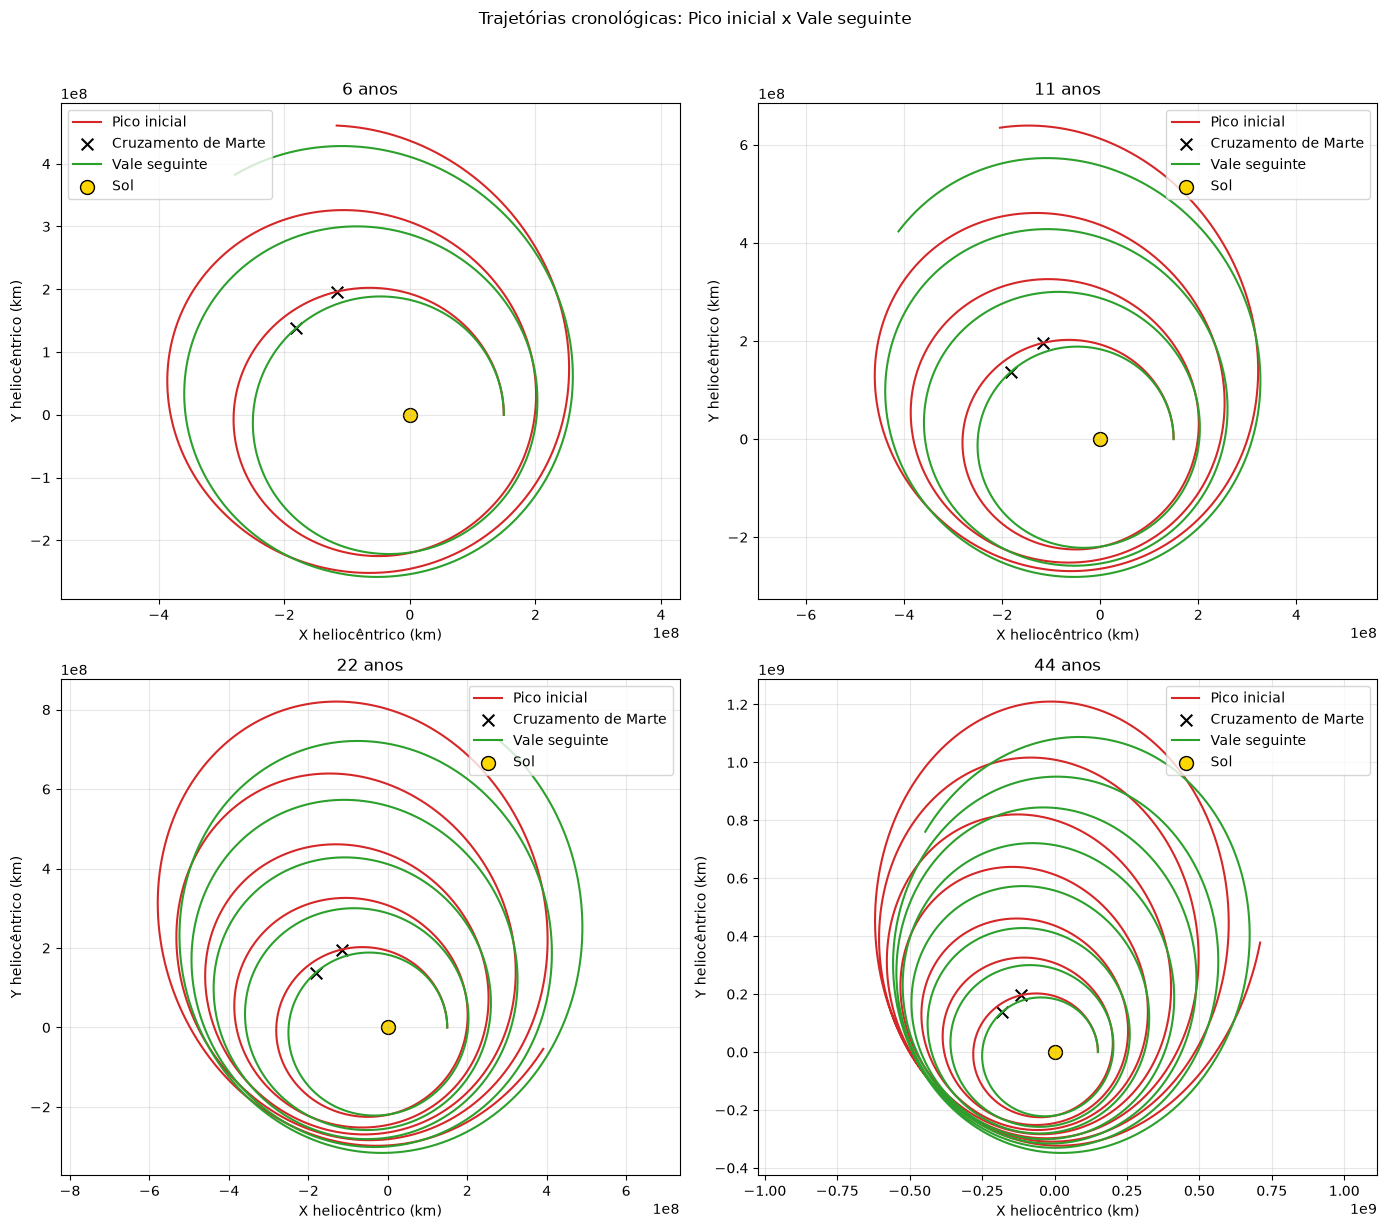

In [12]:
# Trajetórias heliocêntricas: duas datas para cada duração

import matplotlib.pyplot as plt

ncols = len(MISSION_YEARS_BATCH)
nrows = int(np.ceil(ncols / 2))
fig, axes = plt.subplots(
    nrows,
    2,
    figsize=(14, 6 * nrows),
    squeeze=False,
)
axes = axes.ravel()

for axis, mission_years in zip(axes, MISSION_YEARS_BATCH):
    for label, color in (
        (batch_first_label, 'tab:red'),
        (batch_second_label, 'tab:green'),
    ):
        run = shifted_runs[(mission_years, label)]
        df_run = run['df']
        x_relative = df_run['X1'] - df_run['X0']
        y_relative = df_run['Y1'] - df_run['Y0']
        axis.plot(
            x_relative,
            y_relative,
            color=color,
            label=label,
        )

        crossing = run['mars_crossing_position_km']
        if crossing is not None:
            axis.scatter(
                crossing[0],
                crossing[1],
                color='black',
                marker='x',
                s=70,
                label=(
                    'Cruzamento de Marte'
                    if label == batch_first_label
                    else None
                ),
            )

    axis.scatter(
        0,
        0,
        color='gold',
        edgecolor='black',
        s=100,
        label='Sol',
    )
    axis.set_title('{} anos'.format(mission_years))
    axis.set_xlabel('X heliocêntrico (km)')
    axis.set_ylabel('Y heliocêntrico (km)')
    axis.axis('equal')
    axis.grid(True, alpha=0.3)
    axis.legend()

for axis in axes[len(MISSION_YEARS_BATCH):]:
    axis.set_visible(False)

fig.suptitle(
    'Trajetórias cronológicas: {} x {}'.format(
        batch_first_label,
        batch_second_label,
    ),
    y=1.02,
)
fig.tight_layout()
plt.show()
plt.close(fig)

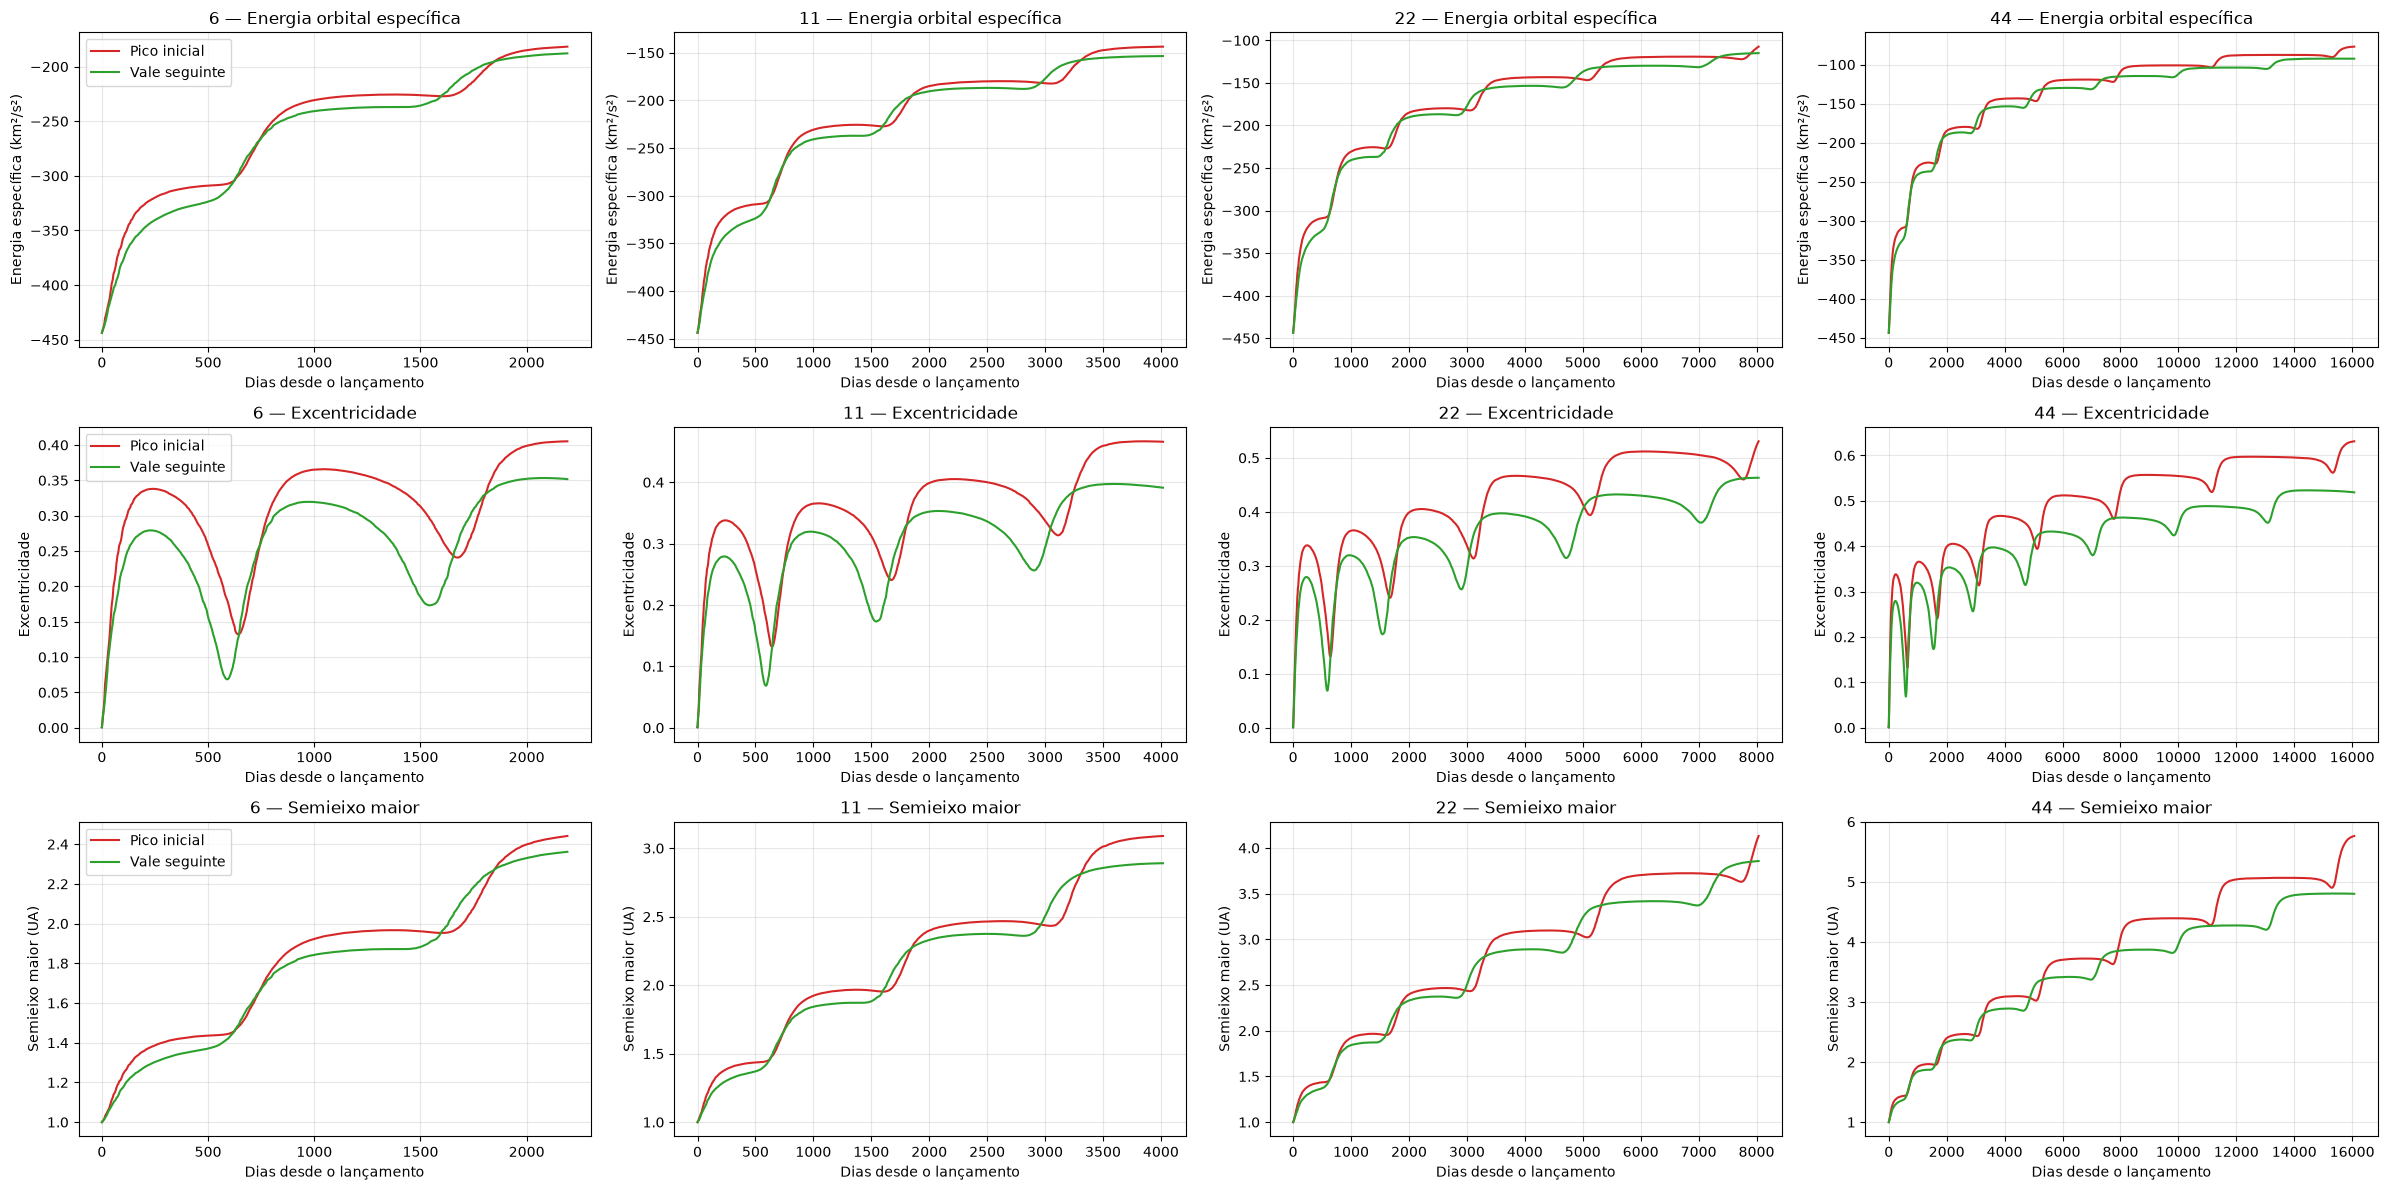

In [13]:
# Elementos orbitais para todas as durações

shifted_orbital = {
    key: orbital_elements_real(run)
    for key, run in shifted_runs.items()
}

fig, axes = plt.subplots(
    3,
    len(MISSION_YEARS_BATCH),
    figsize=(6 * len(MISSION_YEARS_BATCH), 12),
    squeeze=False,
)

orbital_fields = [
    (
        'specific_energy_km2_s2',
        'Energia específica (km²/s²)',
        'Energia orbital específica',
    ),
    (
        'eccentricity',
        'Excentricidade',
        'Excentricidade',
    ),
    (
        'semi_major_axis_AU',
        'Semieixo maior (UA)',
        'Semieixo maior',
    ),
]

for col, mission_years in enumerate(MISSION_YEARS_BATCH):
    for row, (field, ylabel, title) in enumerate(orbital_fields):
        axis = axes[row, col]
        for label, color in (
            (batch_first_label, 'tab:red'),
            (batch_second_label, 'tab:green'),
        ):
            run = shifted_runs[(mission_years, label)]
            elements = shifted_orbital[(mission_years, label)]
            axis.plot(
                elements['elapsed_days'],
                elements[field],
                color=color,
                label=label,
            )
        axis.set_title('{} — {}'.format(mission_years, title))
        axis.set_xlabel('Dias desde o lançamento')
        axis.set_ylabel(ylabel)
        axis.grid(True, alpha=0.3)
        if col == 0:
            axis.legend()

fig.tight_layout()
plt.show()
plt.close(fig)

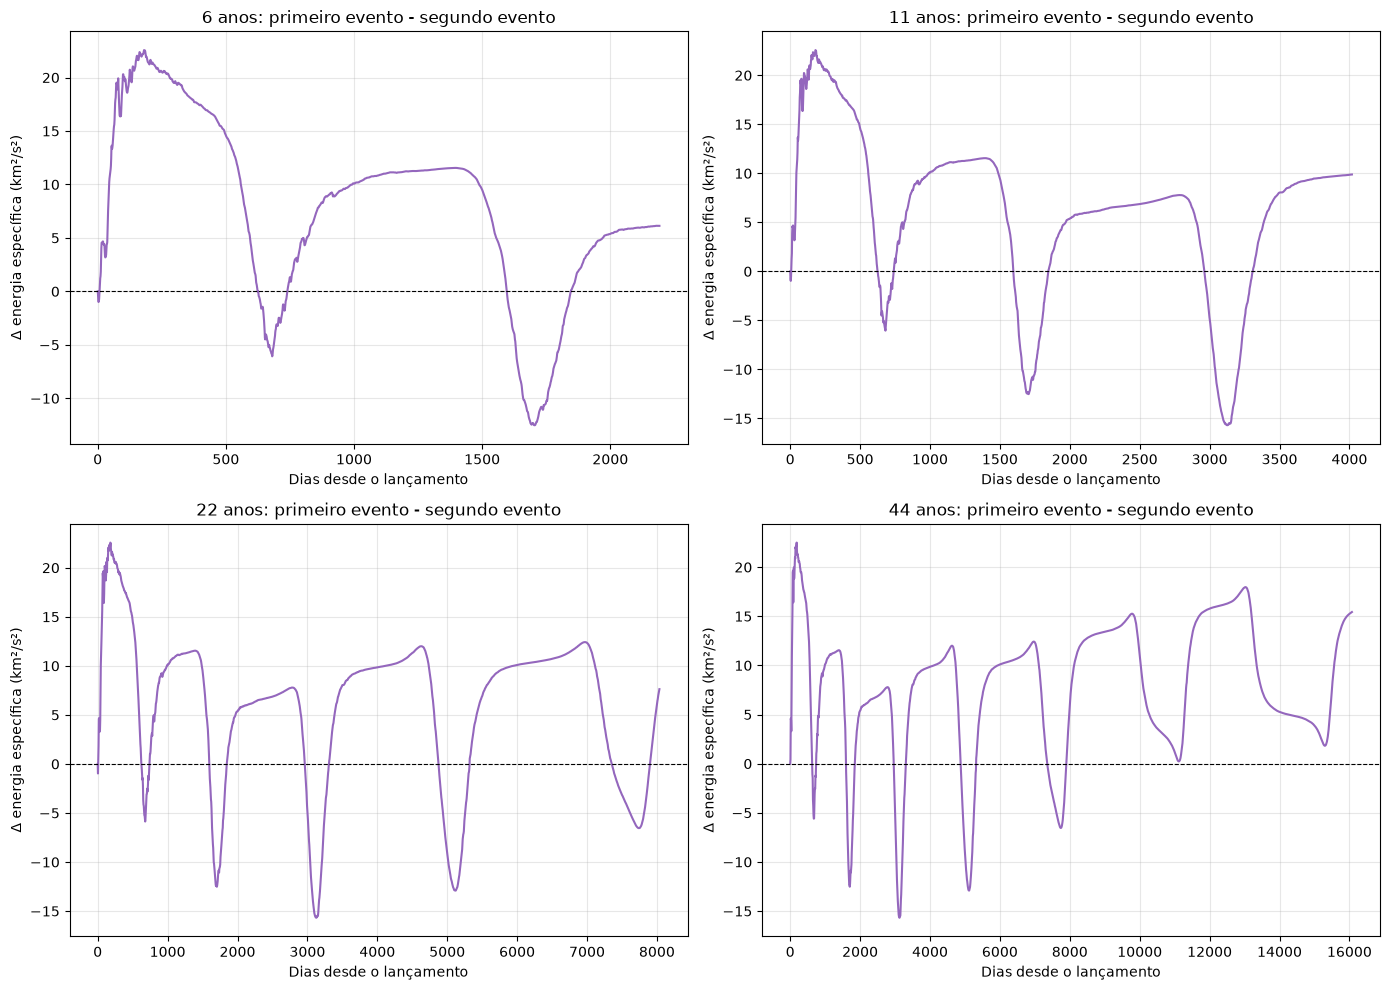

In [14]:
# Diferença de energia orbital entre os dois eventos

shifted_energy_differences = {}

ncols = len(MISSION_YEARS_BATCH)
nrows = int(np.ceil(ncols / 2))
fig, axes = plt.subplots(
    nrows,
    2,
    figsize=(14, 5 * nrows),
    squeeze=False,
)
axes = axes.ravel()

for axis, mission_years in zip(axes, MISSION_YEARS_BATCH):
    first = shifted_orbital[(mission_years, batch_first_label)]
    second = shifted_orbital[(mission_years, batch_second_label)]

    common_max_days = min(
        first['elapsed_days'][-1],
        second['elapsed_days'][-1],
    )
    common_days = np.linspace(0.0, common_max_days, 2000)

    first_energy = np.interp(
        common_days,
        first['elapsed_days'],
        first['specific_energy_km2_s2'],
    )
    second_energy = np.interp(
        common_days,
        second['elapsed_days'],
        second['specific_energy_km2_s2'],
    )
    energy_difference = first_energy - second_energy

    shifted_energy_differences[mission_years] = pd.DataFrame({
        'elapsed_days': common_days,
        'energy_difference_km2_s2': energy_difference,
    })

    axis.plot(
        common_days,
        energy_difference,
        color='tab:purple',
    )
    axis.axhline(0.0, color='black', linestyle='--', linewidth=0.8)
    axis.set_title(
        '{} anos: primeiro evento - segundo evento'.format(mission_years)
    )
    axis.set_xlabel('Dias desde o lançamento')
    axis.set_ylabel('Δ energia específica (km²/s²)')
    axis.grid(True, alpha=0.3)

for axis in axes[len(MISSION_YEARS_BATCH):]:
    axis.set_visible(False)

fig.tight_layout()
plt.show()
plt.close(fig)

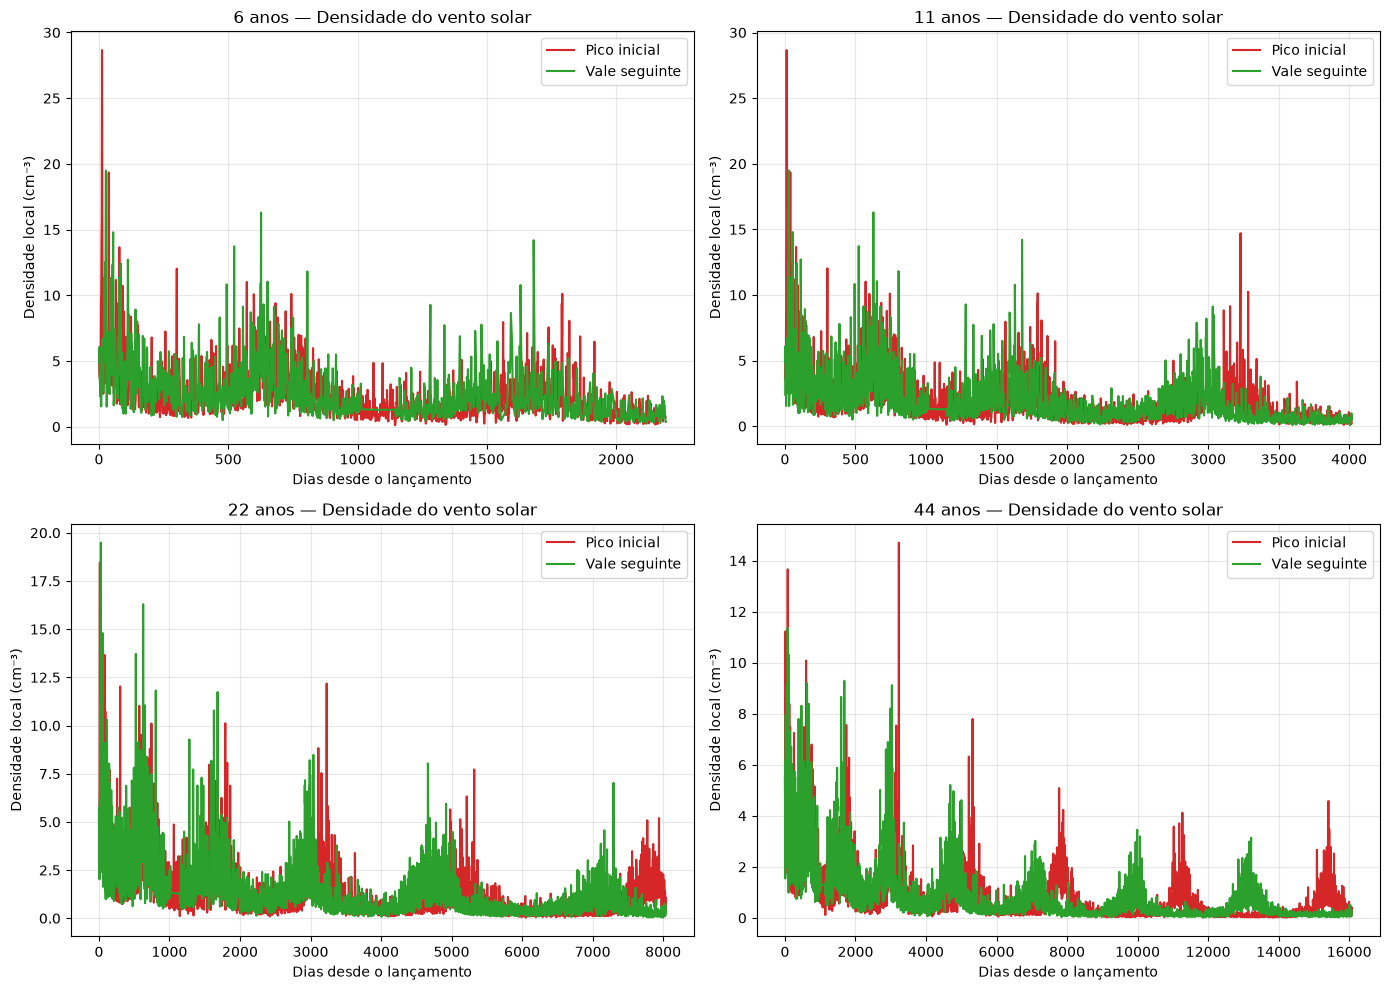

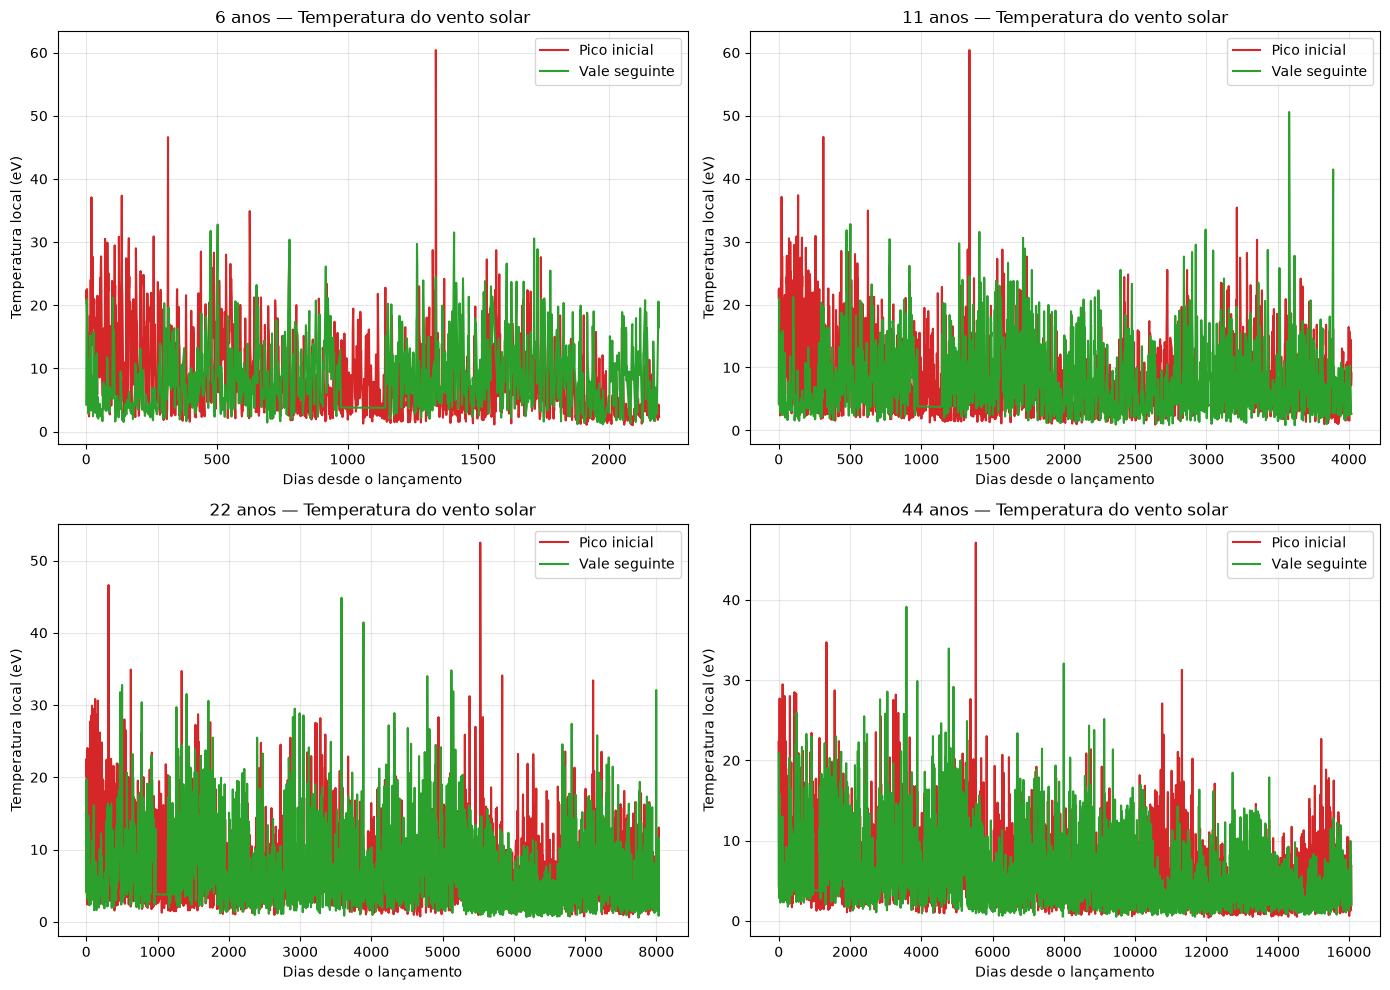

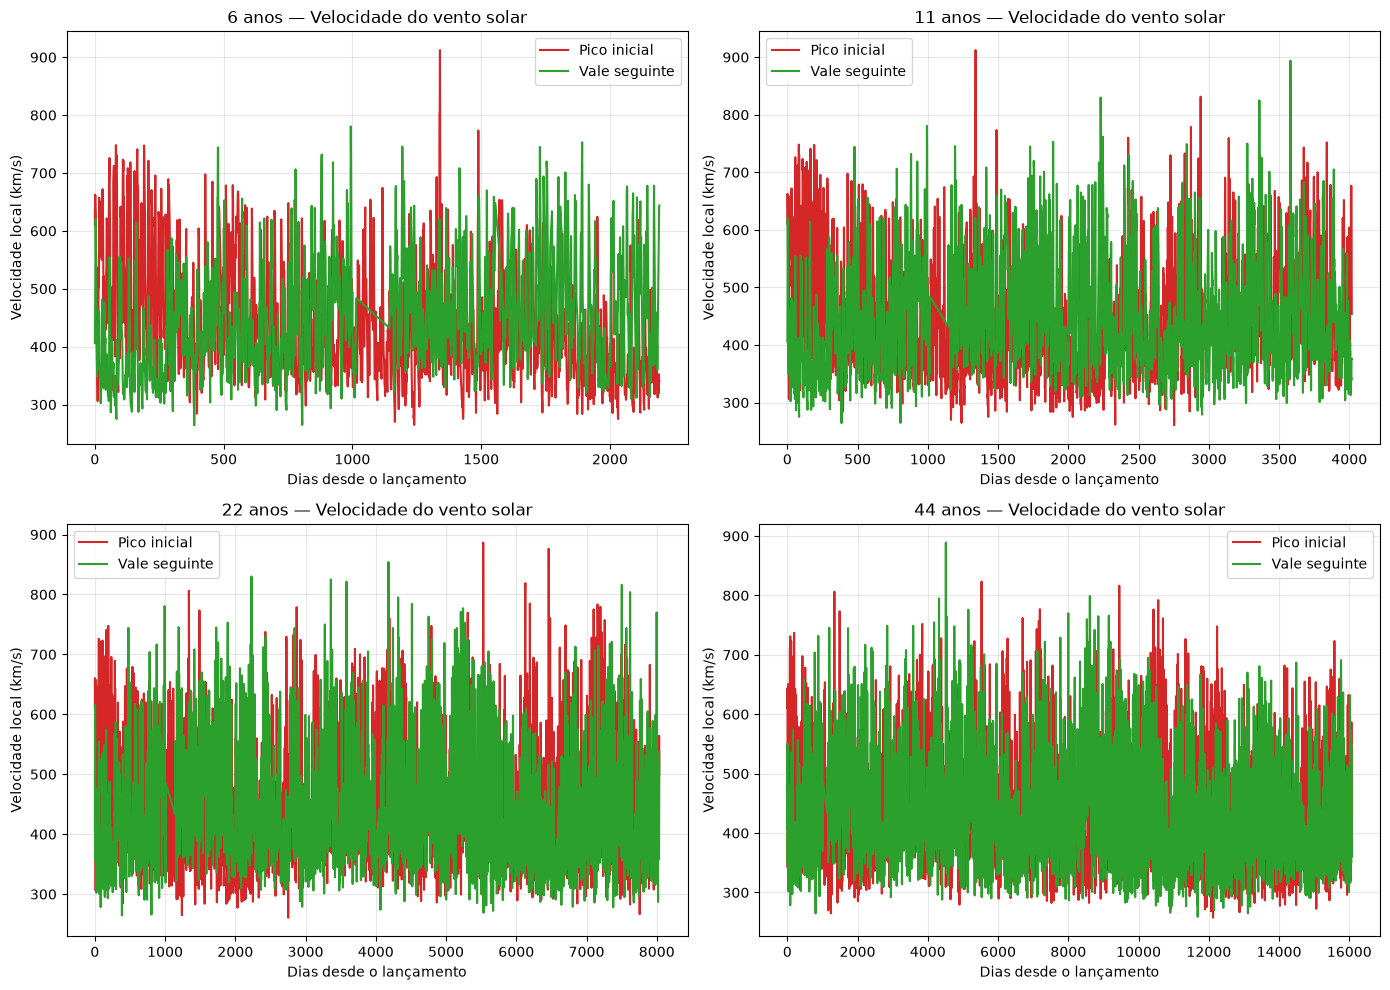

In [15]:
# Propriedades locais do vento solar para todas as durações

shifted_wind_properties = {}
for key, run in shifted_runs.items():
    shifted_wind_properties[key] = local_wind_profile_real(run)

property_specs = [
    ('density_cm3', 'Densidade local (cm⁻³)', 'Densidade do vento solar'),
    ('temperature_eV', 'Temperatura local (eV)', 'Temperatura do vento solar'),
    ('speed_km_s', 'Velocidade local (km/s)', 'Velocidade do vento solar'),
]

ncols = len(MISSION_YEARS_BATCH)
nrows = int(np.ceil(ncols / 2))

for field, ylabel, title in property_specs:
    fig, axes = plt.subplots(
        nrows,
        2,
        figsize=(14, 5 * nrows),
        squeeze=False,
    )
    axes = axes.ravel()

    for axis, mission_years in zip(axes, MISSION_YEARS_BATCH):
        for label, color in (
            (batch_first_label, 'tab:red'),
            (batch_second_label, 'tab:green'),
        ):
            run = shifted_runs[(mission_years, label)]
            profile = shifted_wind_properties[(mission_years, label)]
            axis.plot(
                profile['elapsed_days'],
                profile[field],
                color=color,
                label=label,
            )

        axis.set_title('{} anos — {}'.format(mission_years, title))
        axis.set_xlabel('Dias desde o lançamento')
        axis.set_ylabel(ylabel)
        axis.grid(True, alpha=0.3)
        axis.legend()

    for axis in axes[len(MISSION_YEARS_BATCH):]:
        axis.set_visible(False)

    fig.tight_layout()
    plt.show()
    plt.close(fig)